In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = sorted(glob.glob("huNumbering/*t5a*/"))

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)

    
v2s=[]
v2strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 380:404"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v2s.append(sub)        
    v2strings.append(sub2)
    
    
    
v3s=[]
v3strings=[]
combinedLoopString="resid 415:430"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v3s.append(sub)        
    v3strings.append(sub2)
    
    
    
v123s=[]
v123strings=[]
combinedLoopString="resid 324:345 or resid 377:394 or resid 415:424 or resid 479:385"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v123s.append(sub)        
    v123strings.append(sub2)    

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [3]:
systemFolders

['huNumbering\\rht5a\\', 'huNumbering\\t5a\\', 'huNumbering\\t5ar332p\\']

In [4]:
# Ok let's do PCA
def getPairwiseDists(systems,datasets,selection_strings,stride = 10,EQPOINT=250):
    
    alldists=[]
    for i in range(len(datasets)):
        subdists=[]
        for j in range(len(datasets[i])):
            distances=[]
            for k in range(int(EQPOINT/stride),int(len(systems[i][j].trajectory)/stride)):
                systems[i][j].trajectory[k*stride]
                distances.append(MDAnalysis.analysis.distances.self_distance_array(datasets[i][j].select_atoms("name CA").positions))
            subdists.append(distances)
        alldists.append(subdists)
    return alldists


In [5]:

dists = getPairwiseDists(systems,v123s,v123strings,stride = 1,EQPOINT=EQPOINT)



In [6]:
#save("allpcadists-V2-CApairwise.npy",dists)
#dists=load("allpcadists-V1-CApairwise.npy")

shaped_dists=[]
pca_colours = []
for i in range(len(dists)):
    for j in range(len(dists[i])):
        for k in range(len(dists[i][j])):
            shaped_dists.append(dists[i][j][k])
            pca_colours.append(colourScheme[i])
            
            

Z=sklearn.preprocessing.StandardScaler().fit_transform(shaped_dists)

myPCA=sklearn.decomposition.PCA(n_components=2)
myfit=myPCA.fit(Z)
pcaX=myPCA.transform(Z)
pcaPoints= pcaX.T

In [7]:
#Create a scaler
scaler = sklearn.preprocessing.StandardScaler()
# Fit scaler with the distances from the structures
scaler.fit(shaped_dists)
# get the mean and scale of this transformation
scale_final = scaler.scale_
mean_final = scaler.mean_


scaled_dists = (copy(dists) - mean_final)/scale_final
transformed_dists = []
for i in range(len(scaled_dists)):
    sub=[]
    for j in range(len(scaled_dists[i])):
        sub.append(myPCA.transform(scaled_dists[i][j]))
        
    transformed_dists.append(sub)

Text(0.5, 0, 'PC1')

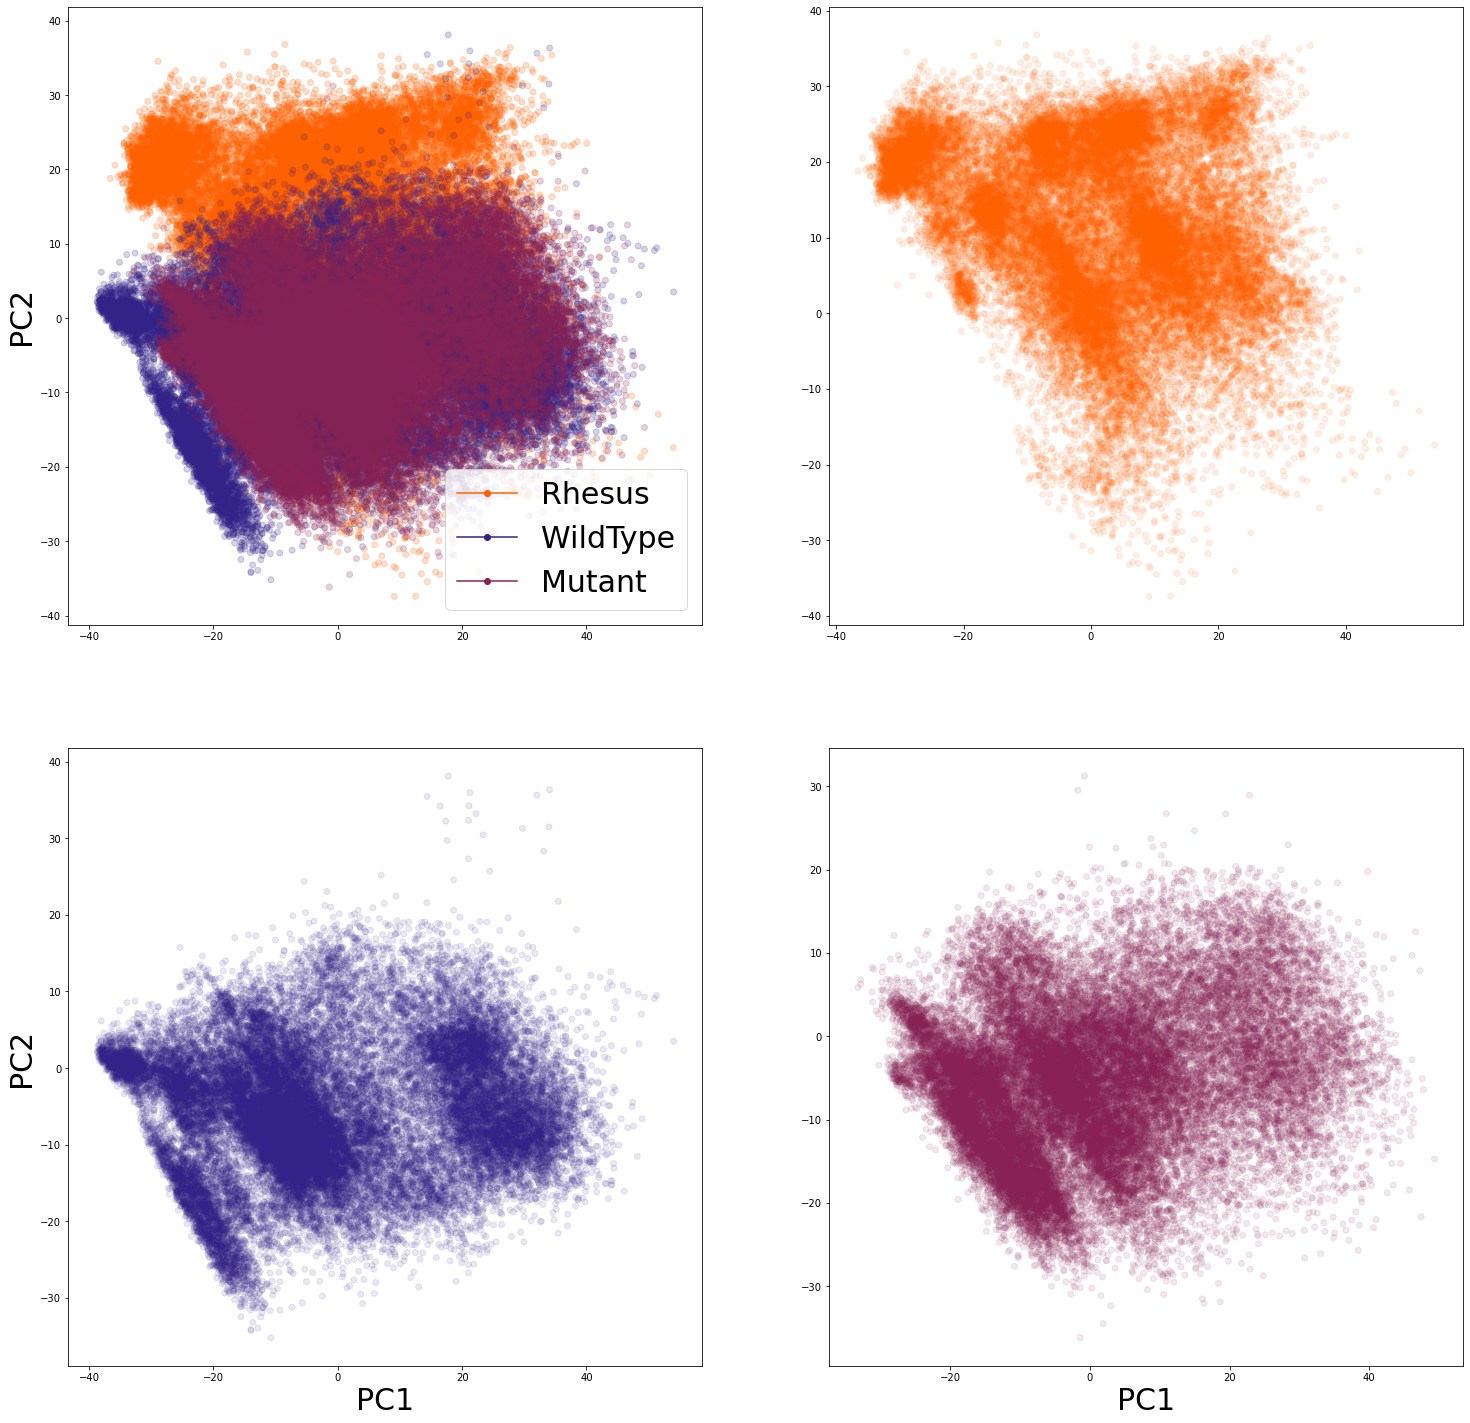

In [8]:
#style.use("ggplot")
figure(figsize = (25,25))
#for i in range(len(pcaPoints.T)):
#    scatter(pcaPoints.T[i][0],pcaPoints.T[i][1],color = pca_colours[i],alpha = 0.1)#,color = mycolors[i])#,label = structureList[i][3:])

subplot(2,2,1)
scatter(*pcaPoints,color = pca_colours,alpha = 0.2)
legend_elements = [Line2D([0], [0], marker='o', color=colourScheme[0], label="Rhesus"),
                       Line2D([0], [0], marker='o', color=colourScheme[1], label="WildType"),
                       Line2D([0], [0], marker='o', color=colourScheme[2], label="Mutant")]
legend(handles = legend_elements,loc='best',fontsize = 30)
ylabel("PC2",fontsize = 30)
#ylim(-18,25)
#xlim(-18,21)
#xticks([])
#yticks([])

subplot(2,2,2)
scatter(pcaPoints[0][:int(len(pcaPoints[0])/3)],pcaPoints[1][:int(len(pcaPoints[0])/3)],color = pca_colours[:int(len(pcaPoints[0])/3)],alpha = 0.1)

#xticks([])
#yticks([])
#ylim(-18,25)
#xlim(-18,21)

subplot(2,2,3)
scatter(pcaPoints[0][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],pcaPoints[1][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],color = pca_colours[int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],alpha = 0.1)

#xticks([])
#yticks([])
#ylim(-18,25)
#xlim(-18,21)
xlabel("PC1",fontsize = 30)
ylabel("PC2",fontsize = 30)


subplot(2,2,4)
scatter(pcaPoints[0][2*int(len(pcaPoints[0])/3):],pcaPoints[1][2*int(len(pcaPoints[0])/3):],color = pca_colours[2*int(len(pcaPoints[0])/3):],alpha = 0.1)
#xticks([])
#yticks([])
#ylim(-18,25)
#xlim(-18,21)
xlabel("PC1",fontsize = 30)


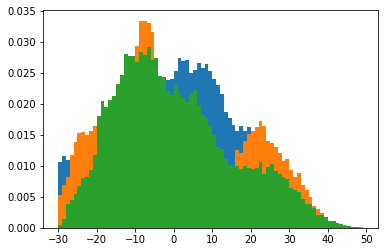

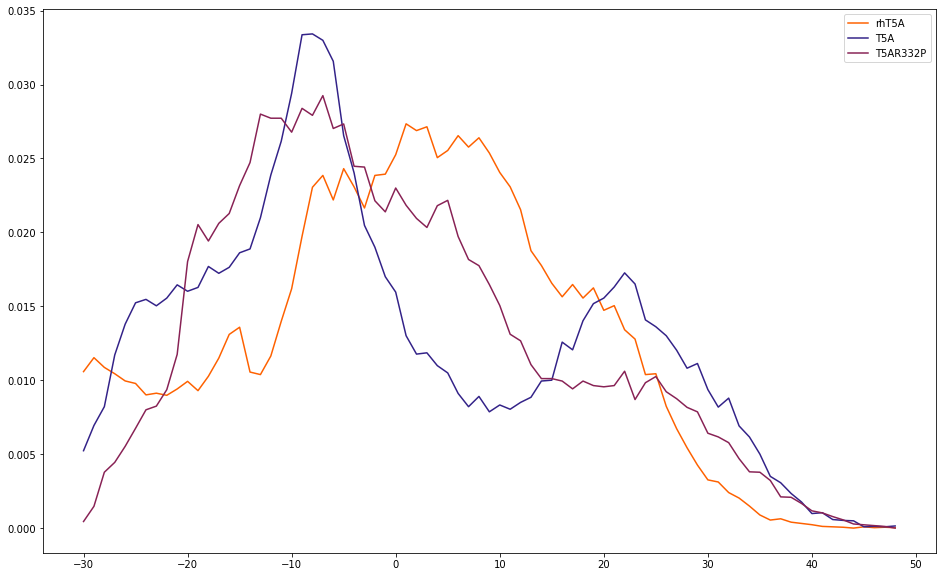

In [9]:
binrange = arange(-30,50,1)

#system_pcaPoints = pcaPoints.reshape(3,2,int(len(pcaPoints[0])/3)) # For some reason this makes things backwards
systempc1s=[]
systempc1s.append(pcaPoints[0][:int(len(pcaPoints[0])/3)])
systempc1s.append(pcaPoints[0][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)])
systempc1s.append(pcaPoints[0][2*int(len(pcaPoints[0])/3):])

    
pc1hists=[]
for i in range(len(systempc1s)):
    a = hist(systempc1s[i],bins = binrange,density = True)[0]
    pc1hists.append(a)
    
    
    
figure(figsize = (16,10))
for i in range(len(pc1hists)):
    plot(binrange[:-1],pc1hists[i],color = threeColor[i],label = system_names[i])
    
legend()





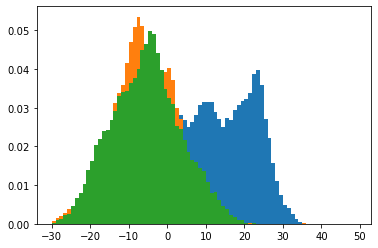

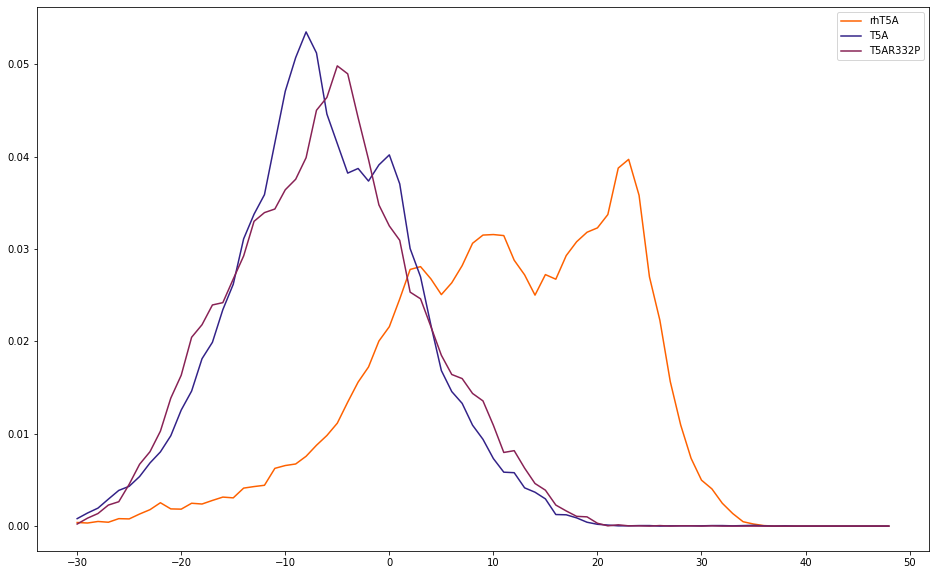

In [10]:
binrange = arange(-30,50,1)

#system_pcaPoints = pcaPoints.reshape(3,2,int(len(pcaPoints[0])/3)) # For some reason this makes things backwards
system_pc2s=[]
system_pc2s.append(pcaPoints[1][:int(len(pcaPoints[1])/3)])
system_pc2s.append(pcaPoints[1][int(len(pcaPoints[1])/3):2*int(len(pcaPoints[1])/3)])
system_pc2s.append(pcaPoints[1][2*int(len(pcaPoints[1])/3):])

    
pc2hists=[]
for i in range(len(system_pc2s)):
    a = hist(system_pc2s[i],bins = binrange,density = True)[0]
    pc2hists.append(a)
    
    
    
figure(figsize = (16,10))
for i in range(len(pc2hists)):
    plot(binrange[:-1],pc2hists[i],color = threeColor[i],label = system_names[i])
    
legend()





C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 49.99999999999995, 'PC1')

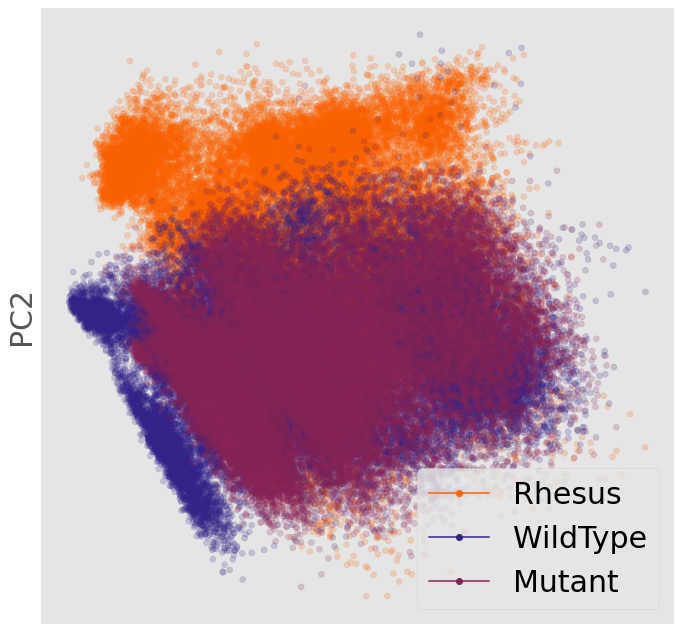

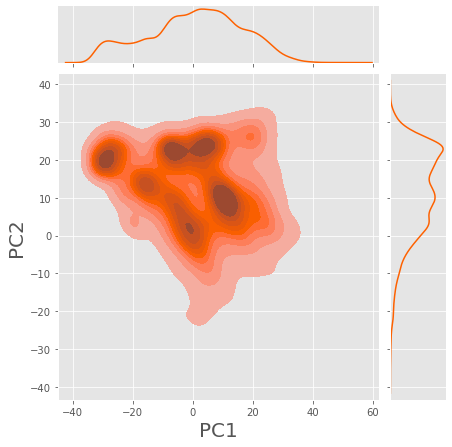

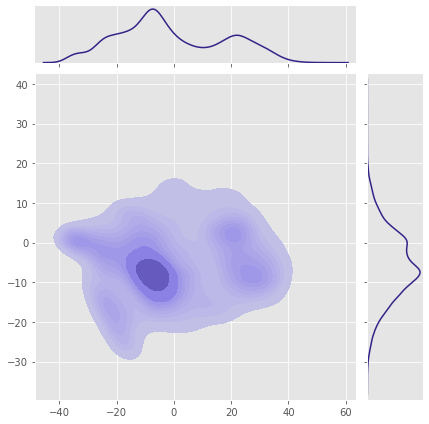

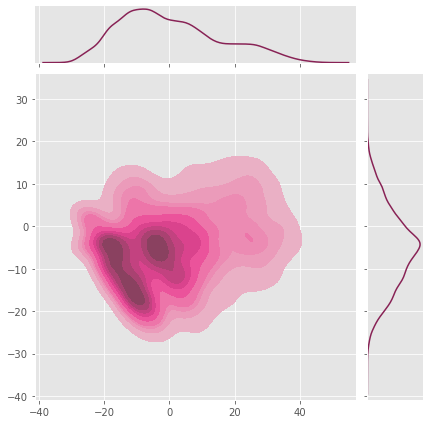

In [11]:
style.use("ggplot")
figure(figsize = (25,25))
#for i in range(len(pcaPoints.T)):
#    scatter(pcaPoints.T[i][0],pcaPoints.T[i][1],color = pca_colours[i],alpha = 0.1)#,color = mycolors[i])#,label = structureList[i][3:])

subplot(2,2,1)
scatter(*pcaPoints,color = pca_colours,alpha = 0.2)
legend_elements = [Line2D([0], [0], marker='o', color=colourScheme[0], label="Rhesus"),
                       Line2D([0], [0], marker='o', color=colourScheme[1], label="WildType"),
                       Line2D([0], [0], marker='o', color=colourScheme[2], label="Mutant")]
legend(handles = legend_elements,loc='best',fontsize = 30)
ylabel("PC2",fontsize = 30)
#ylim(-20,45)
#xlim(-20,50)
xticks([])
yticks([])


h=sns.jointplot(pcaPoints[0][:int(len(pcaPoints[0])/3)],pcaPoints[1][:int(len(pcaPoints[0])/3)],kind = 'kde',shade = True, color=colourScheme[0])
h.set_axis_labels('PC1', 'PC2', fontsize=20)
#h.set
#xticks([])
#yticks([])
#ylim(-20,45)
#xlim(-20,50)
#
sns.jointplot(pcaPoints[0][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],pcaPoints[1][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],kind = 'kde',shade= True, color = colourScheme[1])

#xticks([])
#yticks([])
#ylim(-20,45)
#xlim(-20,50)
xlabel("PC1",fontsize = 30)
ylabel("PC2",fontsize = 30)


sns.jointplot(pcaPoints[0][2*int(len(pcaPoints[0])/3):],pcaPoints[1][2*int(len(pcaPoints[0])/3):],kind = 'kde',shade = True,color=colourScheme[2])
#xticks([])
#yticks([])
#ylim(-20,45)
#xlim(-20,50)
xlabel("PC1",fontsize = 30)


C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Liam\anaconda3\lib\site-packages\seaborn\distributions.py:1181: UserWarning: The following kwargs were not used by contour: 'xlabel'
  cset = contour_func(


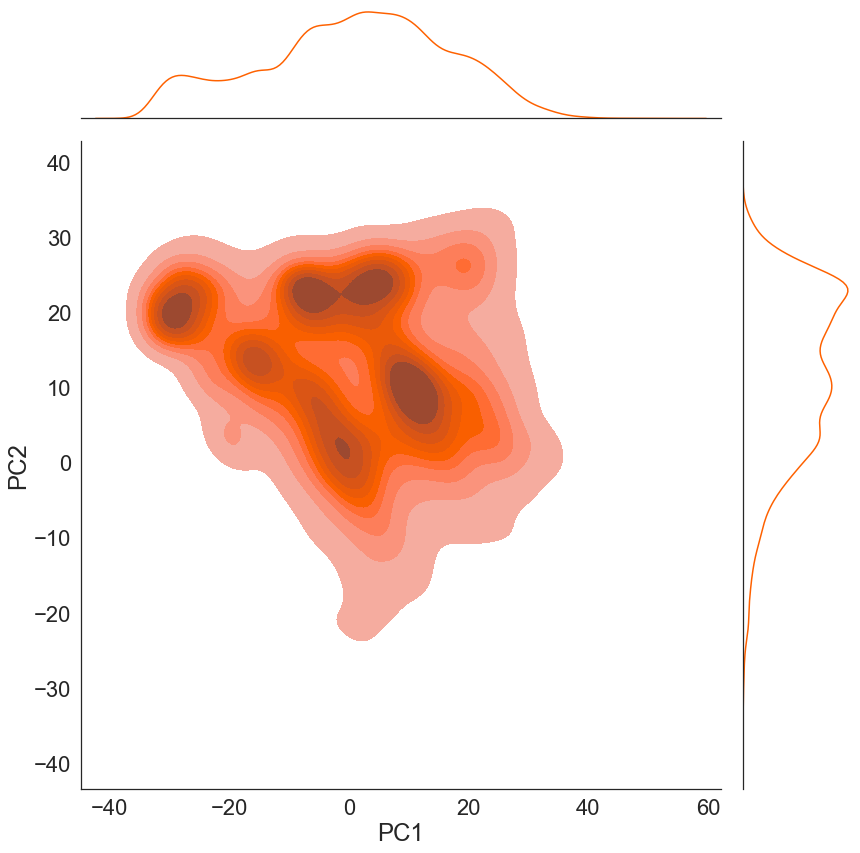

In [12]:
sns.set(font_scale=2,style = "white",rc={"axes.spines.right": False, "axes.spines.top":False})
fig = sns.jointplot(pcaPoints[0][:int(len(pcaPoints[0])/3)],pcaPoints[1][:int(len(pcaPoints[0])/3)],kind = 'kde',shade = True, color=colourScheme[0],xlabel = "PC1",height = 12)

fig.set_axis_labels('PC1','PC2')


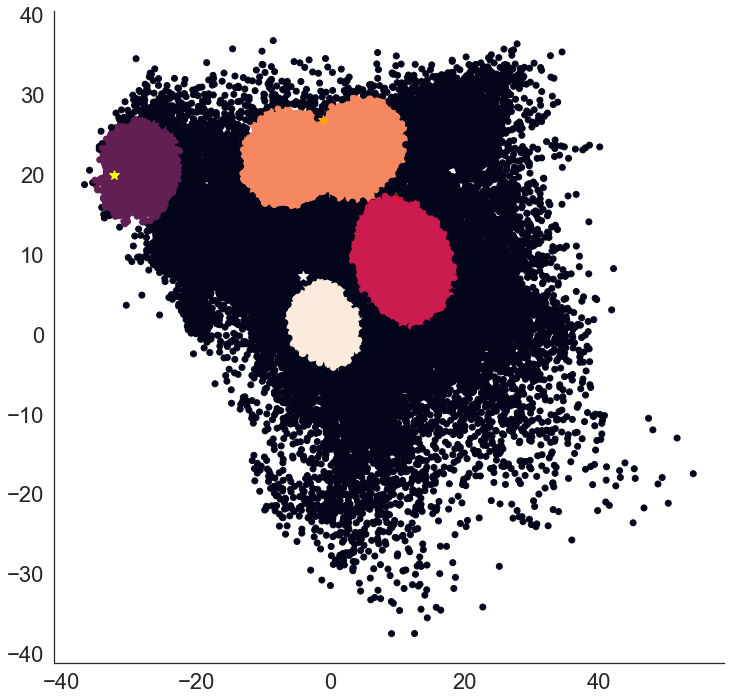

In [13]:
from sklearn.cluster import DBSCAN

#db1 = DBSCAN(eps=.991,min_samples = 127).fit(array(transformed_dists[0]).reshape(-1,2)) # this gives 4 clusters
db1 = DBSCAN(eps=3.9,min_samples = 1400).fit(array(transformed_dists[0]).reshape(-1,2))#2.6, 600 works well for v2 shifted
figure(figsize = (12,12))
plot(array(transformed_dists)[0][0][65][0],array(transformed_dists)[0][0][65][1],"*",color = "crimson",ms = 10)
plot(array(transformed_dists)[0][0][453][0],array(transformed_dists)[0][0][453][1],"*",color = "orange",ms = 10)
plot(array(transformed_dists)[0][1][223][0],array(transformed_dists)[0][1][223][1],"*",color = "yellow",ms = 10)
plot(array(transformed_dists)[0][1][391][0],array(transformed_dists)[0][1][391][1],"*",color = "white",ms = 10)
scatter(array(transformed_dists[0]).reshape(-1,2).T[0],array(transformed_dists[0]).reshape(-1,2).T[1],c = db1.labels_)


In [14]:
#from sklearn.cluster import DBSCAN
#
##db1 = DBSCAN(eps=.991,min_samples = 127).fit(array(transformed_dists[0]).reshape(-1,2)) # this gives 4 clusters
#db1 = DBSCAN(eps=2.5,min_samples = 500).fit(array(transformed_dists[0]).reshape(-1,2))
#figure(figsize = (20,20))
##plot(array(transformed_dists)[0][0][65][0],array(transformed_dists)[0][0][65][1],"*",color = "crimson",ms = 10)
##plot(array(transformed_dists)[0][0][453][0],array(transformed_dists)[0][0][453][1],"*",color = "orange",ms = 10)
##plot(array(transformed_dists)[0][1][223][0],array(transformed_dists)[0][1][223][1],"*",color = "yellow",ms = 10)
##plot(array(transformed_dists)[0][1][391][0],array(transformed_dists)[0][1][391][1],"*",color = "white",ms = 10)
##scatter(array(transformed_dists[0]).reshape(-1,2).T[0],array(transformed_dists[0]).reshape(-1,2).T[1],c = db1.labels_)
#
#colordict = {
#    -1:"black",
#    0:"crimson",
#    1:"darkorange",
#    2:"yellow",
#    3:"white",
#    4:"darkgreen"
#    
#}
#clusterColours=[]
#for i in range(len(db1.labels_)):
#    
#    clusterColours.append(colordict[db1.labels_[i]])
#
#
#
#figure(figsize = (12,12))
#scatter(array(transformed_dists[0]).reshape(-1,2).T[0],array(transformed_dists[0]).reshape(-1,2).T[1],c = clusterColours)
#
#
#xlabel("PC1",fontsize = 25)
#ylabel("PC2",fontsize = 25)
#
#

Text(0, 0.5, 'PC2')

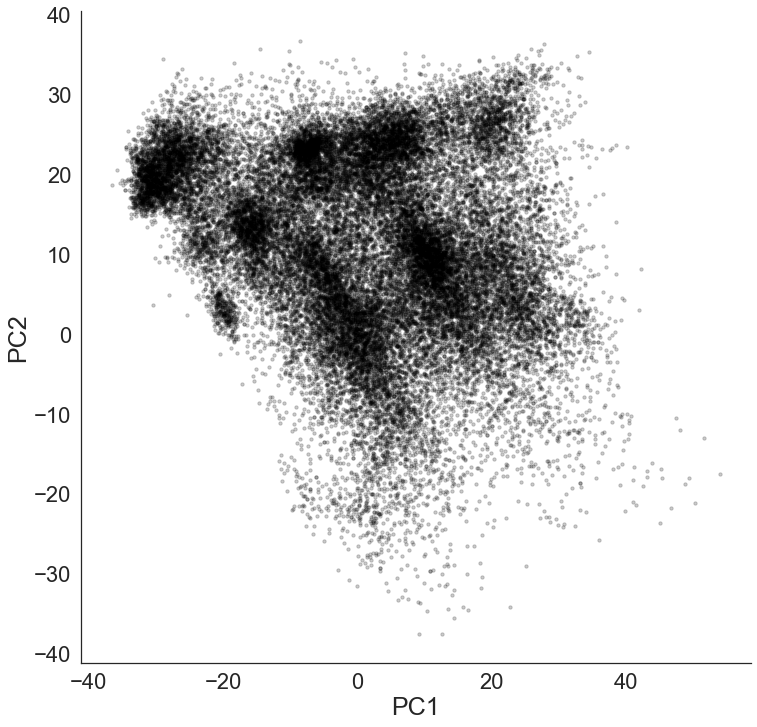

In [15]:

figure(figsize = (12,12))
scatter(array(transformed_dists[0]).reshape(-1,2).T[0],array(transformed_dists[0]).reshape(-1,2).T[1],c = 'black',alpha = 0.2,s = 11)

xlabel("PC1",fontsize = 25)
ylabel("PC2",fontsize = 25)



Text(0, 0.5, 'PC2')

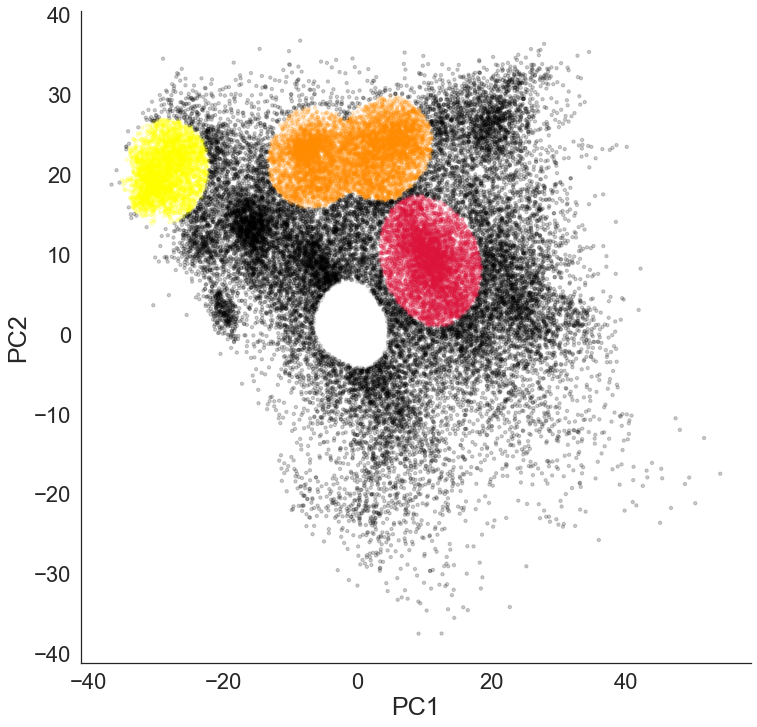

In [16]:
from sklearn.cluster import DBSCAN

#db1 = DBSCAN(eps=.991,min_samples = 127).fit(array(transformed_dists[0]).reshape(-1,2)) # this gives 4 clusters
db1 = DBSCAN(eps=3.9,min_samples = 1400).fit(array(transformed_dists[0]).reshape(-1,2))
#figure(figsize = (20,20))
#plot(array(transformed_dists)[0][0][65][0],array(transformed_dists)[0][0][65][1],"*",color = "crimson",ms = 10)
#plot(array(transformed_dists)[0][0][453][0],array(transformed_dists)[0][0][453][1],"*",color = "orange",ms = 10)
#plot(array(transformed_dists)[0][1][223][0],array(transformed_dists)[0][1][223][1],"*",color = "yellow",ms = 10)
#plot(array(transformed_dists)[0][1][391][0],array(transformed_dists)[0][1][391][1],"*",color = "white",ms = 10)
#scatter(array(transformed_dists[0]).reshape(-1,2).T[0],array(transformed_dists[0]).reshape(-1,2).T[1],c = db1.labels_)

colordict = {
    -1:"black",
    0:"yellow",
    1:"crimson",
    2:"darkorange",
    3:"white",
    4:"darkgreen"
    
}
clusterColours=[]
for i in range(len(db1.labels_)):
    
    clusterColours.append(colordict[db1.labels_[i]])



figure(figsize = (12,12))
#scatter(array(transformed_dists[0]).reshape(-1,2).T[0],array(transformed_dists[0]).reshape(-1,2).T[1],c = clusterColours)
scatter(array(transformed_dists[0]).reshape(-1,2).T[0],array(transformed_dists[0]).reshape(-1,2).T[1],c = clusterColours,alpha = 0.2,s = 11)


xlabel("PC1",fontsize = 25)
ylabel("PC2",fontsize = 25)


Text(0, 0.5, 'PC2')

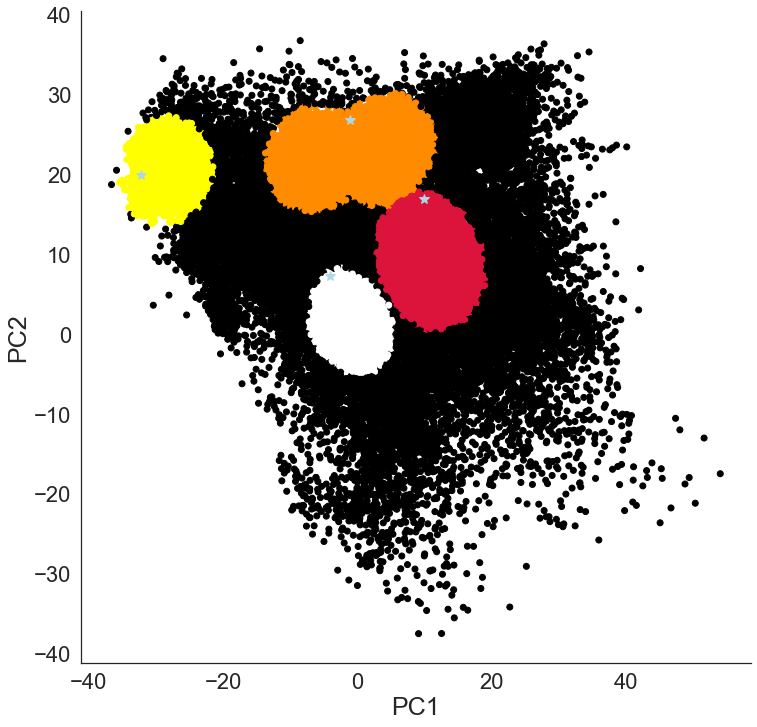

In [17]:
from sklearn.cluster import DBSCAN

#db1 = DBSCAN(eps=.991,min_samples = 127).fit(array(transformed_dists[0]).reshape(-1,2)) # this gives 4 clusters
db1 = DBSCAN(eps=4.15, min_samples = 1500).fit(array(transformed_dists[0]).reshape(-1,2))
#figure(figsize = (20,20))

figure(figsize = (12,12))

plot(array(transformed_dists)[0][0][65][0],array(transformed_dists)[0][0][65][1],"*",color = "lightblue",ms = 10)
plot(array(transformed_dists)[0][0][453][0],array(transformed_dists)[0][0][453][1],"*",color = "lightblue",ms = 10)
plot(array(transformed_dists)[0][1][223][0],array(transformed_dists)[0][1][223][1],"*",color = "lightblue",ms = 10)
plot(array(transformed_dists)[0][1][391][0],array(transformed_dists)[0][1][391][1],"*",color = "lightblue",ms = 10)
#scatter(array(transformed_dists[0]).reshape(-1,2).T[0],array(transformed_dists[0]).reshape(-1,2).T[1],c = db1.labels_)

colordict = {
    -1:"black",
    0:"yellow",
    1:"crimson",
    2:"darkorange",
    3:"white",
    4:"darkgreen"
    
}
clusterColours=[]
for i in range(len(db1.labels_)):
    
    clusterColours.append(colordict[db1.labels_[i]])



scatter(array(transformed_dists[0]).reshape(-1,2).T[0],array(transformed_dists[0]).reshape(-1,2).T[1],c = clusterColours)
#scatter(array(transformed_dists[0]).reshape(-1,2).T[0],array(transformed_dists[0]).reshape(-1,2).T[1],c = clusterColours,alpha = 0.2,s = 11)


xlabel("PC1",fontsize = 25)
ylabel("PC2",fontsize = 25)



In [18]:
#for i in range(len(where(db1.labels_.reshape(9,4001) == 0)[0])):
#    print(where(db1.labels_.reshape(9,4001) == 0)[0][i],where(db1.labels_.reshape(9,4001) == 0)[1][i])
#    with MDAnalysis.Writer(f"v123_pdb_clusters/4State_fixed/State0/state0_trj{where(db1.labels_.reshape(9,4001) == 0)[0][i]}_frame{where(db1.labels_.reshape(9,4001) == 0)[1][i]}.pdb") as W:
#        tu=systems[0][where(db1.labels_.reshape(9,4001) == 0)[0][i]]
#        tu.trajectory[where(db1.labels_.reshape(9,4001) == 0)[1][i]]
#        W.write(tu.select_atoms("protein"))

In [19]:
len(where(db1.labels_.reshape(9,4001) == 0)[0].flatten())

3277

In [20]:
len(where(db1.labels_.reshape(9,4001) == 1)[0].flatten())

5331

In [21]:
len(where(db1.labels_.reshape(9,4001) == 2)[0].flatten())

6739

In [22]:
len(where(db1.labels_.reshape(9,4001) == 3)[0].flatten())

3292

In [23]:
#for i in range(len(where(db1.labels_.reshape(9,4001) == 1)[0])):
#    print(where(db1.labels_.reshape(9,4001) == 1)[0][i],where(db1.labels_.reshape(9,4001) == 1)[1][i])
#    with MDAnalysis.Writer(f"v123_pdb_clusters/4State_fixed/State1/state1_trj{where(db1.labels_.reshape(9,4001) == 1)[0][i]}_frame{where(db1.labels_.reshape(9,4001) == 1)[1][i]}.pdb") as W:
#        tu=systems[0][where(db1.labels_.reshape(9,4001) == 1)[0][i]]
#        tu.trajectory[where(db1.labels_.reshape(9,4001) == 1)[1][i]]
#        W.write(tu.select_atoms("protein"))

In [24]:
#for i in range(len(where(db1.labels_.reshape(9,4001) == 2)[0])):
#    print(where(db1.labels_.reshape(9,4001) == 2)[0][i],where(db1.labels_.reshape(9,4001) == 2)[1][i])
#    with MDAnalysis.Writer(f"v123_pdb_clusters/4State_fixed/State2/state2_trj{where(db1.labels_.reshape(9,4001) == 2)[0][i]}_frame{where(db1.labels_.reshape(9,4001) == 2)[1][i]}.pdb") as W:
#        tu=systems[0][where(db1.labels_.reshape(9,4001) == 2)[0][i]]
#        tu.trajectory[where(db1.labels_.reshape(9,4001) == 2)[1][i]]
#        W.write(tu.select_atoms("protein"))

In [25]:
#for i in range(len(where(db1.labels_.reshape(9,4001) == 3)[0])):
#    print(where(db1.labels_.reshape(9,4001) == 3)[0][i],where(db1.labels_.reshape(9,4001) == 3)[1][i])
#    with MDAnalysis.Writer(f"v123_pdb_clusters/4State_fixed/State3/state3_trj{where(db1.labels_.reshape(9,4001) == 3)[0][i]}_frame{where(db1.labels_.reshape(9,4001) == 3)[1][i]}.pdb") as W:
#        tu=systems[0][where(db1.labels_.reshape(9,4001) == 3)[0][i]]
#        tu.trajectory[where(db1.labels_.reshape(9,4001) == 3)[1][i]]
#        W.write(tu.select_atoms("protein"))

In [26]:
#for i in range(len(where(db1.labels_.reshape(9,4001) == 4)[0])):
#    print(where(db1.labels_.reshape(9,4001) == 4)[0][i],where(db1.labels_.reshape(9,4001) == 4)[1][i])
#    with MDAnalysis.Writer(f"v123_pdb_clusters/4State_fixed/State4/state4_trj{where(db1.labels_.reshape(9,4001) == 4)[0][i]}_frame{where(db1.labels_.reshape(9,4001) == 4)[1][i]}.pdb") as W:
#        tu=systems[0][where(db1.labels_.reshape(9,4001) == 4)[0][i]]
#        tu.trajectory[where(db1.labels_.reshape(9,4001) == 4)[1][i]]
#        W.write(tu.select_atoms("protein"))

In [27]:
#
#
#
#db2 = DBSCAN(eps=.7,min_samples = 175).fit(array(transformed_dists[1]).reshape(-1,2))
#figure(figsize = (8,8))
#scatter(array(transformed_dists[1]).reshape(-1,2).T[0],array(transformed_dists[1]).reshape(-1,2).T[1],c = db2.labels_)
#

In [28]:
#db3 = DBSCAN(eps=.7,min_samples = 175).fit(array(transformed_dists[2]).reshape(-1,2))
#figure(figsize = (8,8))
#scatter(array(transformed_dists[2]).reshape(-1,2).T[0],array(transformed_dists[2]).reshape(-1,2).T[1],c = db3.labels_)
#

In [29]:
#trj_frame_db1_labels = db1.labels_.reshape(9,4001)
#trj_frame_db2_labels = db2.labels_.reshape(9,4001)
#trj_frame_db3_labels = db3.labels_.reshape(9,4001)
#
#
#
##Rhesus
#print("TRJ",where(trj_frame_db1_labels == 0)[0][0],"Frame",where(trj_frame_db1_labels == 0)[1][0])
#print("TRJ",where(trj_frame_db1_labels == 1)[0][0],"Frame",where(trj_frame_db1_labels == 1)[1][0])
#print("TRJ",where(trj_frame_db1_labels == 2)[0][0],"Frame",where(trj_frame_db1_labels == 2)[1][0])
#print("TRJ",where(trj_frame_db1_labels == 3)[0][0],"Frame",where(trj_frame_db1_labels == 3)[1][0])
#

In [30]:
#for i in range(len(where(trj_frame_db1_labels == 0)[0])):
#    print(where(trj_frame_db1_labels == 0)[0][i],where(trj_frame_db1_labels == 0)[1][i])
#    with MDAnalysis.Writer(f"v123_pdb_clusters/state1_trj{where(trj_frame_db1_labels == 0)[0][i]}_frame{where(trj_frame_db1_labels == 0)[1][i]}.pdb") as W:
#        tu=systems[0][where(trj_frame_db1_labels == 0)[0][i]]
#        tu.trajectory[where(trj_frame_db1_labels == 0)[1][i]]
#        W.write(tu.select_atoms("protein"))
#

In [31]:
#for i in range(len(where(trj_frame_db1_labels == 1)[0])):
#    print(where(trj_frame_db1_labels == 1)[0][i],where(trj_frame_db1_labels == 1)[1][i])
#    with MDAnalysis.Writer(f"v123_pdb_clusters/State1/state2_trj{where(trj_frame_db1_labels == 1)[0][i]}_frame{where(trj_frame_db1_labels == 1)[1][i]}.pdb") as W:
#        tu=systems[0][where(trj_frame_db1_labels == 1)[0][i]]
#        tu.trajectory[where(trj_frame_db1_labels == 1)[1][i]]
#        W.write(tu.select_atoms("protein"))
#

In [32]:
#for i in range(len(where(trj_frame_db1_labels == 2)[0])):
#    print(where(trj_frame_db1_labels == 2)[0][i],where(trj_frame_db1_labels == 2)[1][i])
#    with MDAnalysis.Writer(f"v123_pdb_clusters/State2/state3_trj{where(trj_frame_db1_labels == 2)[0][i]}_frame{where(trj_frame_db1_labels == 2)[1][i]}.pdb") as W:
#        tu=systems[0][where(trj_frame_db1_labels == 2)[0][i]]
#        tu.trajectory[where(trj_frame_db1_labels == 2)[1][i]]
#        W.write(tu.select_atoms("protein"))
#

In [33]:
#for i in range(len(where(trj_frame_db1_labels == 3)[0])):
#    print(where(trj_frame_db1_labels == 3)[0][i],where(trj_frame_db1_labels == 3)[1][i])
#    with MDAnalysis.Writer(f"v123_pdb_clusters/State3/state4_trj{where(trj_frame_db1_labels == 3)[0][i]}_frame{where(trj_frame_db1_labels == 3)[1][i]}.pdb") as W:
#        tu=systems[0][where(trj_frame_db1_labels == 3)[0][i]]
#        tu.trajectory[where(trj_frame_db1_labels == 3)[1][i]]
#        W.write(tu.select_atoms("protein"))
#

In [34]:



##WT
#print("TRJ",where(trj_frame_db2_labels == 0)[0][0],where(trj_frame_db2_labels == 0)[1][0])
#

In [35]:
##RF332P
#print("TRJ",where(trj_frame_db3_labels == 0)[0][0],"Frame", where(trj_frame_db3_labels == 0)[1][0])
#print("TRJ",where(trj_frame_db3_labels == 1)[0][0],"Frame", where(trj_frame_db3_labels == 1)[1][0])
#

In [36]:
#with MDAnalysis.Writer("state_dbscan_outputs_rhesus_3loopstate_1_trj0_frame65.pdb") as W:
#    
#    tu=systems[0][0]
#    tu.trajectory[65]
#    W.write(tu.select_atoms("protein"))
#    
#with MDAnalysis.Writer("state_dbscan_outputs_rhesus_3loopstate_2_trj0_frame453.pdb") as W:
#    
#    tu=systems[0][0]
#    tu.trajectory[453]
#    W.write(tu.select_atoms("protein"))
#    
#with MDAnalysis.Writer("state_dbscan_outputs_rhesus_3loopstate_3_trj1_frame223.pdb") as W:
#    
#    tu=systems[0][1]
#    tu.trajectory[223]
#    W.write(tu.select_atoms("protein"))
#    
#with MDAnalysis.Writer("state_dbscan_outputs_rhesus_3loopstate_4_trj1_frame391.pdb") as W:
#    
#    tu=systems[0][1]
#    tu.trajectory[391]
#    W.write(tu.select_atoms("protein"))

In [37]:
#with MDAnalysis.Writer("state_dbscan_outputs_wt_3loopstate_1_trj0_frame13.pdb") as W:
#    
#    tu=systems[1][0]
#    tu.trajectory[13]
#    W.write(tu.select_atoms("protein"))

In [38]:
#with MDAnalysis.Writer("state_dbscan_outputs_r332p_3loopstate_1_trj0_frame31.pdb") as W:
#    
#    tu=systems[2][0]
#    tu.trajectory[31]
#    W.write(tu.select_atoms("protein"))
#    
#with MDAnalysis.Writer("state_dbscan_outputs_r332p_3loopstate_1_trj0_frame82.pdb") as W:
#    
#    tu=systems[2][0]
#    tu.trajectory[82]
#    W.write(tu.select_atoms("protein"))